-----------DAY-6---------

In [1]:
#Import libraries
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder ,  StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report , f1_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
import warnings 
warnings.filterwarnings("ignore")

PROGRAM-1

CSV file created successfully.


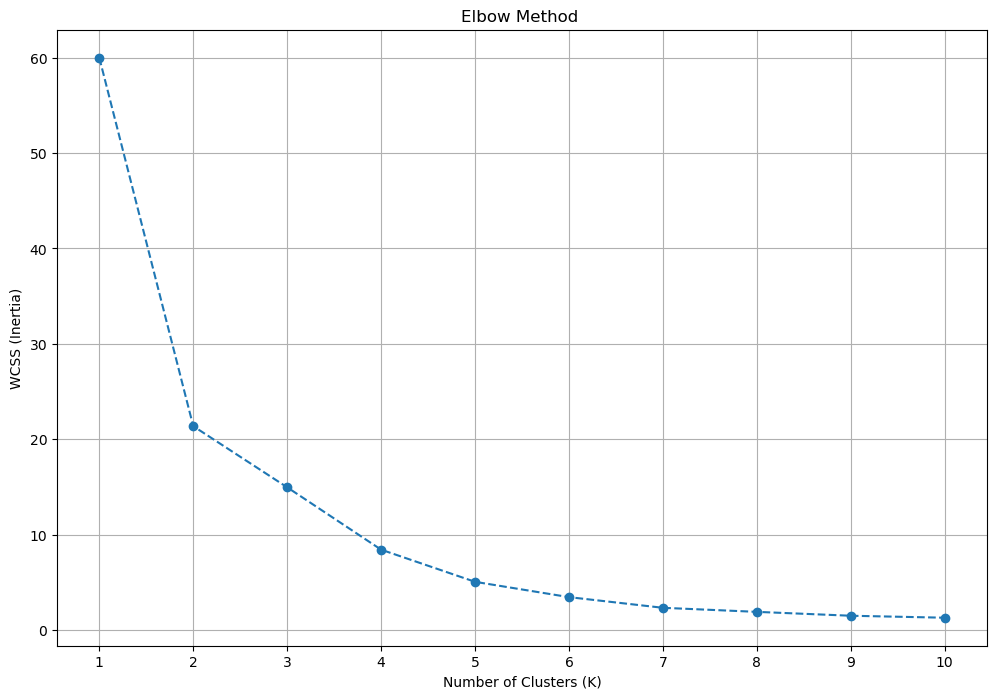

In [2]:
# Apply K-Means on Mall Customers dataset; plot elbow curve 
# Sample data with 30 customers
data = {
    "CustomerID": list(range(1, 31)),
    "Gender": [
        "Male", "Female", "Female", "Male", "Female",
        "Male", "Female", "Male", "Female", "Male",
        "Female", "Male", "Female", "Male", "Female",
        "Male", "Female", "Male", "Female", "Male",
        "Female", "Male", "Female", "Male", "Female",
        "Male", "Female", "Male", "Female", "Male"           ],
    "Age": [
        19, 21, 20, 23, 31,
        22, 35, 24, 29, 30,
        27, 32, 26, 28, 33,
        25, 36, 40, 38, 42,
        45, 41, 39, 34, 37,
        43, 46, 48, 50, 52              ],
    "Annual Income (k$)": [
        15, 16, 17, 18, 19,
        20, 22, 24, 25, 28,
        30, 32, 35, 38, 40,
        42, 45, 48, 50, 55,
        58, 60, 63, 65, 68,
        70, 72, 75, 78, 80               ],
    "Spending Score (1-100)": [
        39, 81, 6, 77, 40,
        76, 35, 72, 50, 65,
        48, 60, 55, 58, 45,
        52, 40, 38, 42, 35,
        30, 28, 25, 20, 18,
        15, 12, 10, 8, 5                  ]}
# Create DataFrame
df = pd.DataFrame(data)

# Save as CSV file
df.to_csv('Mall_Customers.csv', index=False)
print("CSV file created successfully.")

#Load dataset
data = pd.read_csv('Mall_Customers.csv')

# Select relevant features (Annual Income & Spending Score)
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow method (finding optimal k)
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot elbow curve
plt.figure(figsize=(12 , 8))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title("Elbow Method ")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Inertia)")
plt.xticks(range(1, 11))
plt.grid()
plt.show()

PROGRAM-2

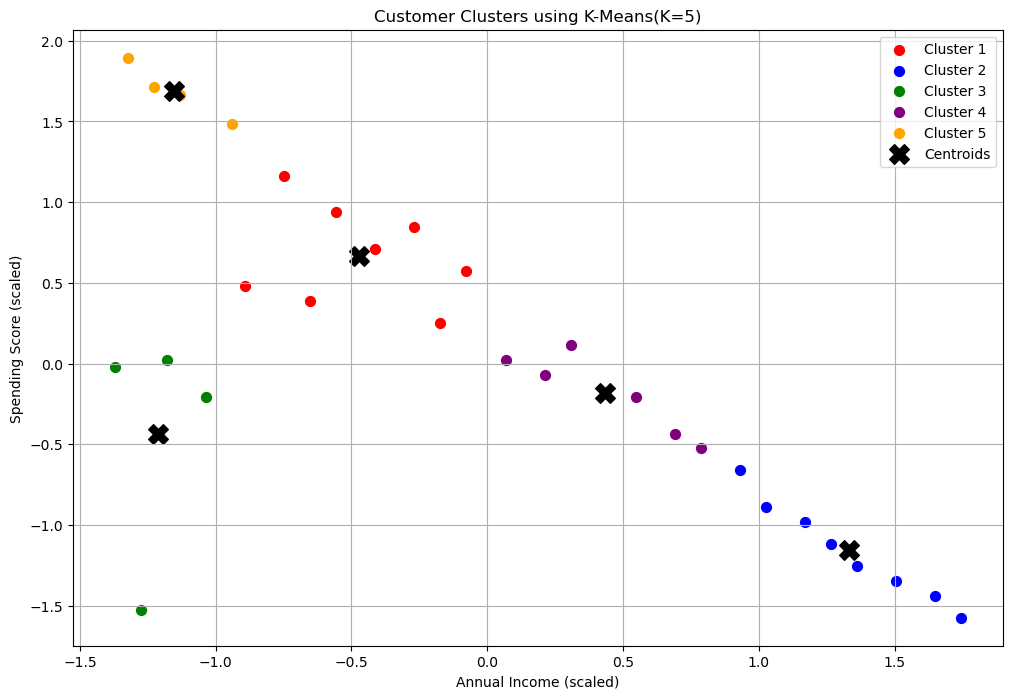

In [3]:
#Visualise clusters using scatter plot with colour-coded labels 
# Load dataset
data = pd.read_csv("Mall_Customers.csv")

# Select features
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train K-Means (choose K=5 from elbow method)
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
labels = kmeans.fit_predict(X_scaled)

# Add cluster labels to dataframe
data['Cluster'] = labels

# Plot clusters
plt.figure(figsize=(12 , 8))
plt.scatter(
    X_scaled[labels == 0, 0], X_scaled[labels == 0, 1],
    s=50, c='red', label='Cluster 1'                           )
plt.scatter(
    X_scaled[labels == 1, 0], X_scaled[labels == 1, 1],
    s=50, c='blue', label='Cluster 2'                            )
plt.scatter(
    X_scaled[labels == 2, 0], X_scaled[labels == 2, 1],
    s=50, c='green', label='Cluster 3'                           )
plt.scatter(
    X_scaled[labels == 3, 0], X_scaled[labels == 3, 1],
    s=50, c='purple', label='Cluster 4'                          )
plt.scatter(
    X_scaled[labels == 4, 0], X_scaled[labels == 4, 1],
    s=50, c='orange', label='Cluster 5'                           )

# Plot centroids
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=200, c='black', marker='X', label='Centroids'               )

plt.title("Customer Clusters using K-Means(K=5)")
plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.legend()
plt.grid()
plt.show()

PROGRAM-3

Explained Variance Ratio: [0.72962445 0.22850762]


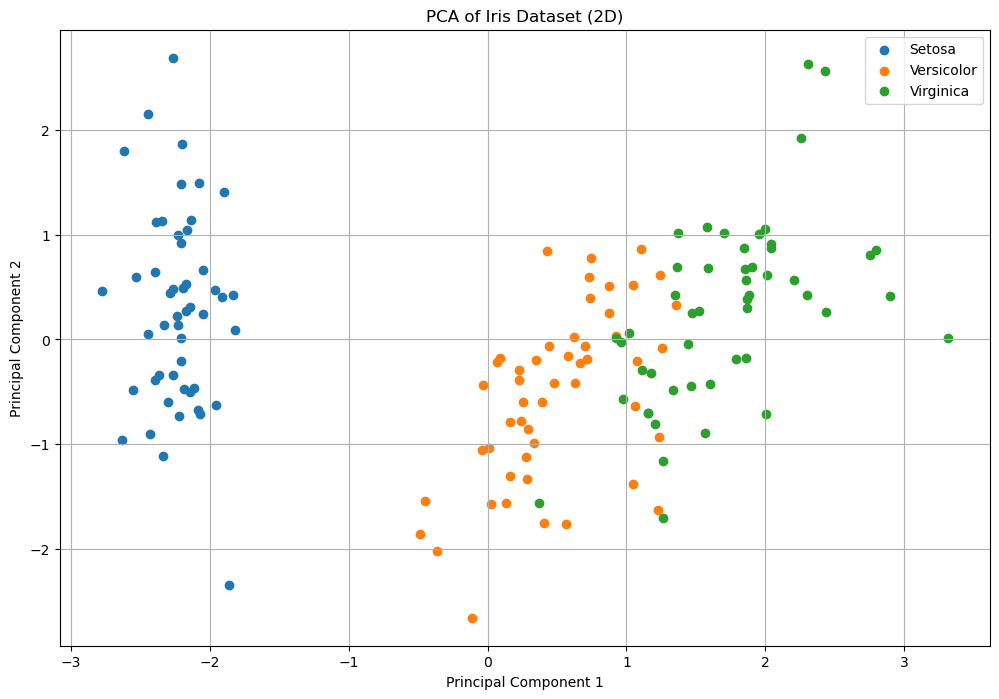

In [4]:
#Apply PCA to reduce Iris to 2D and visualise 
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA

# Load dataset
iris = load_iris()

# Features and target
X= iris.data
y = iris.target

# Standardize features (important for PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA (reduce to 2 components)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Explained variance
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

# Plot PCA result
plt.figure(figsize=(12 , 8))
plt.scatter(X_pca[y == 0, 0], X_pca[y == 0, 1], label='Setosa')
plt.scatter(X_pca[y == 1, 0], X_pca[y == 1, 1], label='Versicolor')
plt.scatter(X_pca[y == 2, 0], X_pca[y == 2, 1], label='Virginica')

plt.title("PCA of Iris Dataset (2D)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid()
plt.show()

PROGRAM-4

In [5]:
# Reconstruct data from top 2 components and measure variance explained 
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA

# Load dataset
iris = load_iris()
X = iris.data

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA (2 components)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Reconstruct data from 2 components
X_reconstructed = pca.inverse_transform(X_pca)

# Variance explained
print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total Variance Explained:", sum(pca.explained_variance_ratio_))

# Reconstruction error (MSE)
mse = np.mean((X_scaled - X_reconstructed) ** 2)
print("Reconstruction Error (MSE):", mse)

# Optional: compare original vs reconstructed (first 5 samples)
print("\nOriginal (scaled) vs Reconstructed (first 5 samples):")
for i in range(5):
    print("Original:", np.round(X_scaled[i], 2))
    print("Reconstructed:", np.round(X_reconstructed[i], 2))
    print("---"*15)

Explained Variance Ratio: [0.72962445 0.22850762]
Total Variance Explained: 0.9581320720000164
Reconstruction Error (MSE): 0.0418679279999836

Original (scaled) vs Reconstructed (first 5 samples):
Original: [-0.9   1.02 -1.34 -1.32]
Reconstructed: [-1.    1.05 -1.3  -1.25]
---------------------------------------------
Original: [-1.14 -0.13 -1.34 -1.32]
Reconstructed: [-1.34 -0.06 -1.22 -1.22]
---------------------------------------------
Original: [-1.39  0.33 -1.4  -1.32]
Reconstructed: [-1.36  0.32 -1.38 -1.36]
---------------------------------------------
Original: [-1.51  0.1  -1.28 -1.32]
Reconstructed: [-1.42  0.07 -1.35 -1.34]
---------------------------------------------
Original: [-1.02  1.25 -1.34 -1.32]
Reconstructed: [-1.    1.24 -1.37 -1.31]
---------------------------------------------


--------PRACTICE SHEET----------

PROGRAM-5

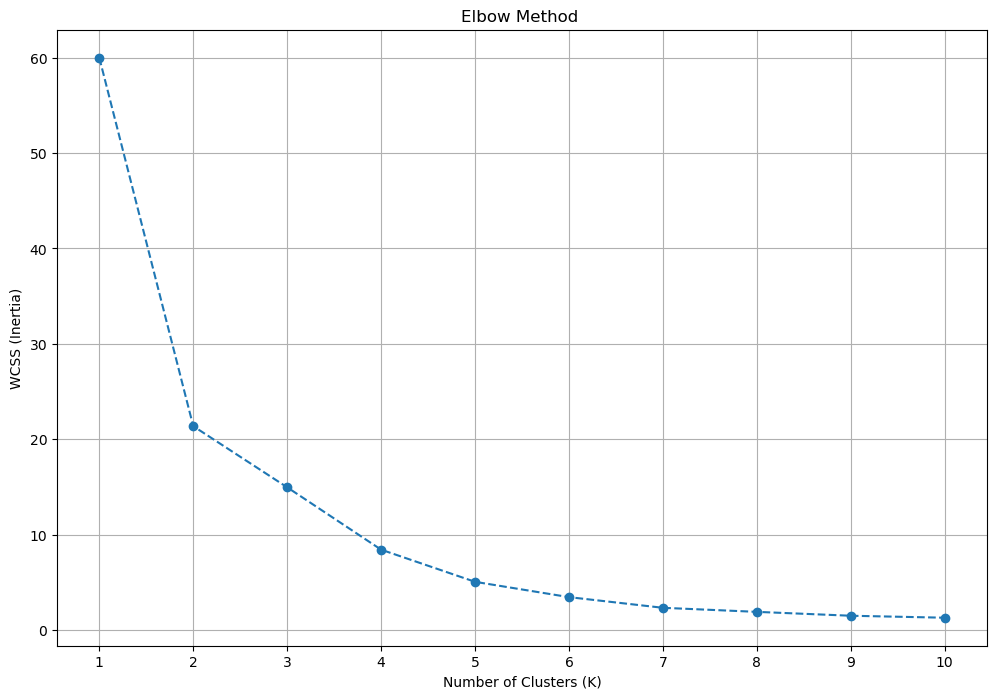

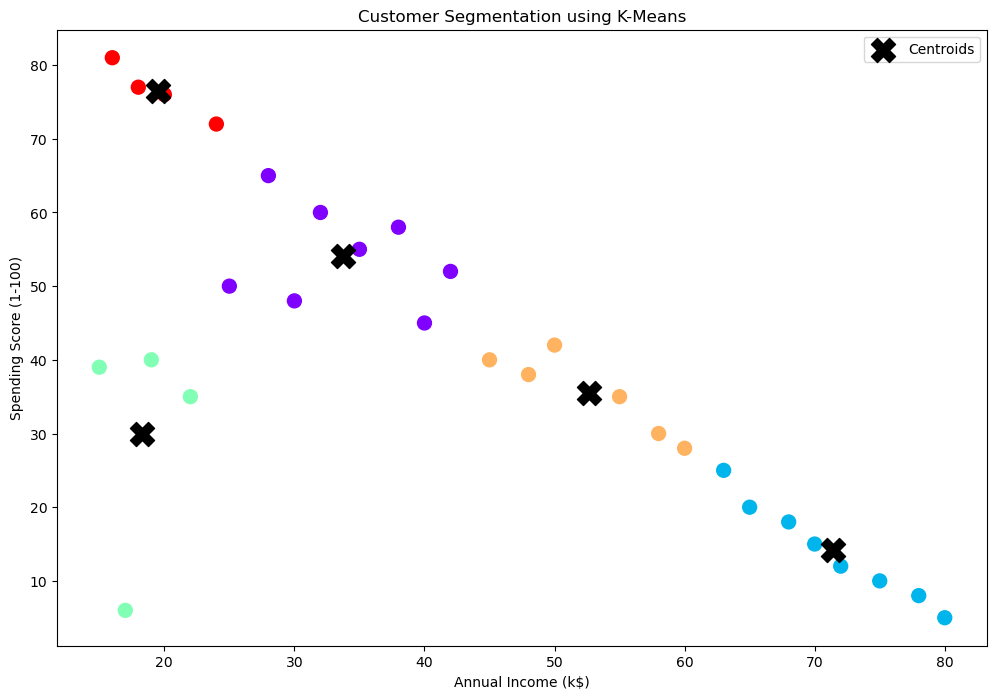


Cluster 0
    CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
8            9  Female   29                  25                      50   
9           10    Male   30                  28                      65   
10          11  Female   27                  30                      48   
11          12    Male   32                  32                      60   
12          13  Female   26                  35                      55   
13          14    Male   28                  38                      58   
14          15  Female   33                  40                      45   
15          16    Male   25                  42                      52   

    Cluster  
8         0  
9         0  
10        0  
11        0  
12        0  
13        0  
14        0  
15        0  

Cluster 1
    CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
22          23  Female   39                  63                      25   
23          24    Male   3

In [6]:
# Customer segmentation mini-project using K-Means 
# Load the Dataset


#Load dataset
data = pd.read_csv('Mall_Customers.csv')

# Select relevant features (Annual Income & Spending Score)
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow method (finding optimal k)
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot elbow curve
plt.figure(figsize=(12 , 8))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title("Elbow Method ")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Inertia)")
plt.xticks(range(1, 11))
plt.grid()
plt.show()

#Apply K-Means
kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)

#Visualize the Clusters
plt.figure(figsize=(12 , 8))
plt.scatter(
    X['Annual Income (k$)'],
    X['Spending Score (1-100)'],
    c=df['Cluster'],
    cmap='rainbow',
    s=100                         )

# Plot centroids
plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=300,
    c='black',
    marker='X',
    label='Centroids'           )

plt.title('Customer Segmentation using K-Means')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

#Display Customers in Each Cluster
for i in range(5):
    print(f"\nCluster {i}")
    print(df[df['Cluster'] == i])



PROGRAM-6

In [7]:
#Apply PCA before KNN and compare accuracy with/without PCA 
# Load dataset
iris = load_iris()

# Features and target
X = iris.data
y = iris.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


#--------------KNN without PCA---------------
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)
accuracy_without_pca = accuracy_score(y_test, y_pred)
print("Accuracy without PCA:" , round(accuracy_without_pca * 100, 2), "%")

# ----------Apply PCA--------------
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

#-------------KNN with PCA----------------
knn_pca = KNeighborsClassifier(n_neighbors=5)
knn_pca.fit(X_train_pca, y_train)
y_pred_pca = knn_pca.predict(X_test_pca)
accuracy_with_pca = accuracy_score(y_test, y_pred_pca)
print("Accuracy with PCA:" , round(accuracy_with_pca * 100, 2), "%")

Accuracy without PCA: 100.0 %
Accuracy with PCA: 93.33 %
